In [1]:
!pip install datasets

In [2]:
from datasets import load_dataset
import pandas as pd

In [3]:
dataset = load_dataset("CShorten/ML-ArXiv-Papers", split="train")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [4]:
df = pd.DataFrame(dataset)
df.head()

,Unnamed: 0.1,Unnamed: 0,title,abstract
0,0,0.0,Learning from compressed observations,The problem of statistical learning is to co...
1,1,1.0,Sensor Networks with Random Links: Topology De...,"In a sensor network, in practice, the commun..."
2,2,2.0,The on-line shortest path problem under partia...,The on-line shortest path problem is conside...
3,3,3.0,A neural network approach to ordinal regression,Ordinal regression is an important type of l...
4,4,4.0,Parametric Learning and Monte Carlo Optimization,This paper uncovers and explores the close r...


In [5]:
df = df[["title", "abstract"]]

In [6]:
df = df.head(15000)

In [7]:
df["paper_text"] = df["title"] + " " + df["abstract"]

In [8]:
df["paper_text"] = df["paper_text"].str.replace("\n", " ", regex=False)
df["paper_text"] = df["paper_text"].str.strip()

In [9]:
df["paper_text"].iloc[0]

'Learning from compressed observations   The problem of statistical learning is to construct a predictor of a random variable $Y$ as a function of a related random variable $X$ on the basis of an i.i.d. training sample from the joint distribution of $(X,Y)$. Allowable predictors are drawn from some specified class, and the goal is to approach asymptotically the performance (expected loss) of the best predictor in the class. We consider the setting in which one has perfect observation of the $X$-part of the sample, while the $Y$-part has to be communicated at some finite bit rate. The encoding of the $Y$-values is allowed to depend on the $X$-values. Under suitable regularity conditions on the admissible predictors, the underlying family of probability distributions and the loss function, we give an information-theoretic characterization of achievable predictor performance in terms of conditional distortion-rate functions. The ideas are illustrated on the example of nonparametric regres

In [10]:
df.shape

(15000, 3)

In [11]:
!pip install sentence-transformers

In [12]:
from sentence_transformers import SentenceTransformer

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

In [13]:
model = SentenceTransformer("all-MiniLM-L6-v2")

In [14]:
print(type(model))

<class 'sentence_transformers.sentence_transformer.model.SentenceTransformer'>


In [15]:
sample_text = df["paper_text"].iloc[0]
sample_text

'Learning from compressed observations   The problem of statistical learning is to construct a predictor of a random variable $Y$ as a function of a related random variable $X$ on the basis of an i.i.d. training sample from the joint distribution of $(X,Y)$. Allowable predictors are drawn from some specified class, and the goal is to approach asymptotically the performance (expected loss) of the best predictor in the class. We consider the setting in which one has perfect observation of the $X$-part of the sample, while the $Y$-part has to be communicated at some finite bit rate. The encoding of the $Y$-values is allowed to depend on the $X$-values. Under suitable regularity conditions on the admissible predictors, the underlying family of probability distributions and the loss function, we give an information-theoretic characterization of achievable predictor performance in terms of conditional distortion-rate functions. The ideas are illustrated on the example of nonparametric regres

In [16]:
sample_embedding = model.encode(sample_text)

print(type(sample_embedding))
print(sample_embedding.shape)

<class 'numpy.ndarray'>
(384,)


In [17]:
sample_embedding[:20]

array([-0.1315641 , -0.00678266, -0.00367612,  0.03265158,  0.11219642,
        0.01227267,  0.09816719, -0.0900523 ,  0.04231161, -0.01977348,
       -0.03308417,  0.07452948,  0.10632038, -0.02060429, -0.02052106,
        0.00169493,  0.07081953,  0.05854454, -0.11231912,  0.02082474],
      dtype=float32)

In [18]:
sample_embeddings = model.encode(df["paper_text"].head(5).tolist())

In [19]:
sample_embeddings.shape

(5, 384)

In [20]:
from sklearn.metrics.pairwise import cosine_similarity

In [21]:
similarity = cosine_similarity(
    sample_embeddings[0].reshape(1, -1),
    sample_embeddings[0].reshape(1, -1)
)

print(similarity)

[[1.0000001]]


In [22]:
similarity = cosine_similarity(
    sample_embeddings[0].reshape(1, -1),
    sample_embeddings[1].reshape(1, -1)
)

print(similarity)

[[0.36625272]]


In [23]:
for i in range(1, 5):

    similarity = cosine_similarity(
        sample_embeddings[0].reshape(1, -1),
        sample_embeddings[i].reshape(1, -1)
    )

    print(f"Paper {i} Similarity:", similarity[0][0])

Paper 1 Similarity: 0.36625272
Paper 2 Similarity: 0.33522844
Paper 3 Similarity: 0.15505108
Paper 4 Similarity: 0.37421533


In [24]:
embeddings = model.encode(
    df["paper_text"].tolist(),
    batch_size=32,
    show_progress_bar=True
)

Batches:   0%|          | 0/469 [00:00<?, ?it/s]

In [25]:
print(type(embeddings))
print(embeddings.shape)
print(embeddings.dtype)

<class 'numpy.ndarray'>
(15000, 384)
float32


In [26]:
import os
import numpy as np

In [27]:
if os.path.exists("paper_embeddings.npy"):
    print("Loading saved embeddings...")
    embeddings = np.load("paper_embeddings.npy")
else:
    print("Generating embeddings...")
    embeddings = model.encode(
        df["paper_text"].tolist(),
        batch_size=32,
        show_progress_bar=True
    )
    np.save("paper_embeddings.npy", embeddings)
    print("Embeddings saved successfully!")

Loading saved embeddings...


In [28]:
print(type(embeddings))
print(embeddings.shape)
print(embeddings.dtype)

<class 'numpy.ndarray'>
(15000, 384)
float32


In [29]:
!pip install faiss-cpu

In [30]:
import faiss

In [31]:
faiss.normalize_L2(embeddings)

In [32]:
index = faiss.IndexFlatIP(embeddings.shape[1])

In [33]:
index.add(embeddings)

In [34]:
print(index.ntotal)

15000


In [35]:
query = "Deep learning for medical image analysis"

In [36]:
query_embedding = model.encode([query])
query_embedding.shape

(1, 384)

In [37]:
faiss.normalize_L2(query_embedding)

In [38]:
D, I = index.search(query_embedding, 5)

print(D)
print(I)

[[0.6807244  0.67092204 0.65219975 0.62811744 0.61311525]]
[[10466 13730 11873 12691 11282]]


In [39]:
for score, idx in zip(D[0], I[0]):
    print("Title:", df.iloc[idx]["title"])
    print("Abstract:", df.iloc[idx]["abstract"][:300])
    print("Similarity Score:", round(score, 4))
    print("-" * 80)

Title: A Perspective on Deep Imaging
Abstract:   The combination of tomographic imaging and deep learning, or machine learning
in general, promises to empower not only image analysis but also image
reconstruction. The latter aspect is considered in this perspective article
with an emphasis on medical imaging to develop a new generation of image

Similarity Score: 0.6807
--------------------------------------------------------------------------------
Title: Convolutional Neural Networks for Medical Image Analysis: Full Training
  or Fine Tuning?
Abstract:   Training a deep convolutional neural network (CNN) from scratch is difficult
because it requires a large amount of labeled training data and a great deal of
expertise to ensure proper convergence. A promising alternative is to fine-tune
a CNN that has been pre-trained using, for instance, a large 
Similarity Score: 0.6709
--------------------------------------------------------------------------------
Title: Classification of MRI dat

In [40]:
import time

start = time.time()
D, I = index.search(query_embedding, 5)
end = time.time()

print(f"Search Time: {end-start:.4f} seconds")

Search Time: 0.0031 seconds


In [41]:
def search_paper(query, k=5):

    query_embedding = model.encode([query])
    faiss.normalize_L2(query_embedding)

    D, I = index.search(query_embedding, k)

    for score, idx in zip(D[0], I[0]):
        print("Title:", df.iloc[idx]["title"])
        print("Abstract:", df.iloc[idx]["abstract"][:300])
        print("Similarity Score:", round(score, 4))
        print("-" * 80)

    return D, I

In [42]:
search_paper("Deep learning for medical image analysis")

Title: A Perspective on Deep Imaging
Abstract:   The combination of tomographic imaging and deep learning, or machine learning
in general, promises to empower not only image analysis but also image
reconstruction. The latter aspect is considered in this perspective article
with an emphasis on medical imaging to develop a new generation of image

Similarity Score: 0.6807
--------------------------------------------------------------------------------
Title: Convolutional Neural Networks for Medical Image Analysis: Full Training
  or Fine Tuning?
Abstract:   Training a deep convolutional neural network (CNN) from scratch is difficult
because it requires a large amount of labeled training data and a great deal of
expertise to ensure proper convergence. A promising alternative is to fine-tune
a CNN that has been pre-trained using, for instance, a large 
Similarity Score: 0.6709
--------------------------------------------------------------------------------
Title: Classification of MRI dat

(array([[0.6807244 , 0.67092204, 0.65219975, 0.62811744, 0.61311525]],
       dtype=float32),
 array([[10466, 13730, 11873, 12691, 11282]]))

In [43]:
!pip install transformers==4.48.0

In [44]:
from transformers import pipeline
summarizer = pipeline(
    task="summarization",
    model="facebook/bart-large-cnn",
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cpu


In [45]:
type(summarizer)

transformers.pipelines.text2text_generation.SummarizationPipeline

In [46]:
summary = summarizer(df.iloc[10466]["abstract"], max_length=120 , min_length=40)
print(summary)

[{'summary_text': 'The combination of tomographic imaging and deep learning, or machine learning, promises to empower not only image analysis but also image reconstructions. This direction might lead to intelligent utilization of domain knowledge from big data, innovativeapproaches for image reconstruction, and superior performance in clinical applications.'}]


In [47]:
type(summary)

list

In [48]:
type(summary[0])

dict

In [49]:
summary[0]["summary_text"]

'The combination of tomographic imaging and deep learning, or machine learning, promises to empower not only image analysis but also image reconstructions. This direction might lead to intelligent utilization of domain knowledge from big data, innovativeapproaches for image reconstruction, and superior performance in clinical applications.'

In [50]:
for score,idx in zip(D[0],I[0]):
  print("Similarity score", score)
  print("Title",df.iloc[idx]["title"])
  print("Abstract",df.iloc[idx]["abstract"][:500])

  summary = summarizer(df.iloc[idx]["abstract"], max_length=120 , min_length=40)
  print(summary)
  print(summary[0]["summary_text"])
  print()


Similarity score 0.6807244
Title A Perspective on Deep Imaging
Abstract   The combination of tomographic imaging and deep learning, or machine learning
in general, promises to empower not only image analysis but also image
reconstruction. The latter aspect is considered in this perspective article
with an emphasis on medical imaging to develop a new generation of image
reconstruction theories and techniques. This direction might lead to
intelligent utilization of domain knowledge from big data, innovative
approaches for image reconstruction, and superior performance
[{'summary_text': 'The combination of tomographic imaging and deep learning, or machine learning, promises to empower not only image analysis but also image reconstructions. This direction might lead to intelligent utilization of domain knowledge from big data, innovativeapproaches for image reconstruction, and superior performance in clinical applications.'}]
The combination of tomographic imaging and deep learning, or mac

In [51]:
def search_and_summarize(query , k=5):
  query_embedding = model.encode([query])
  faiss.normalize_L2(query_embedding)
  D,I=index.search(query_embedding,k)
  for score,idx in zip(D[0],I[0]):
    print("Similarity score", score)
    print("Title",df.iloc[idx]["title"])
    print("Abstract",df.iloc[idx]["abstract"][:500])
    print()

  summary = summarizer(df.iloc[idx]["abstract"], max_length=120 , min_length=40 , do_sample=False)
  print(summary)
  print(summary[0]["summary_text"])
  print()


In [52]:
search_and_summarize("Deep learning in medical imaging", k=5)

Similarity score 0.73549855
Title A Perspective on Deep Imaging
Abstract   The combination of tomographic imaging and deep learning, or machine learning
in general, promises to empower not only image analysis but also image
reconstruction. The latter aspect is considered in this perspective article
with an emphasis on medical imaging to develop a new generation of image
reconstruction theories and techniques. This direction might lead to
intelligent utilization of domain knowledge from big data, innovative
approaches for image reconstruction, and superior performance

Similarity score 0.6881736
Title Classification of MRI data using Deep Learning and Gaussian
  Process-based Model Selection
Abstract   The classification of MRI images according to the anatomical field of view is
a necessary task to solve when faced with the increasing quantity of medical
images. In parallel, advances in deep learning makes it a suitable tool for
computer vision problems. Using a common architecture (suc

In [53]:
pip install keybert==0.8.5

In [54]:
from keybert import KeyBERT

In [55]:
kw_model = KeyBERT(model)

In [56]:
type(kw_model)

keybert._model.KeyBERT

In [57]:
print(df.iloc[10466]["abstract"])

  The combination of tomographic imaging and deep learning, or machine learning
in general, promises to empower not only image analysis but also image
reconstruction. The latter aspect is considered in this perspective article
with an emphasis on medical imaging to develop a new generation of image
reconstruction theories and techniques. This direction might lead to
intelligent utilization of domain knowledge from big data, innovative
approaches for image reconstruction, and superior performance in clinical and
preclinical applications. To realize the full impact of machine learning on
medical imaging, major challenges must be addressed.



In [58]:
text =df.iloc[10466]["abstract"]
keywords = kw_model.extract_keywords(text)

In [59]:
print(keywords)
print(type(keywords))
print(type(keywords[0]))

[('imaging', 0.4528), ('tomographic', 0.4488), ('reconstruction', 0.3623), ('deep', 0.3003), ('learning', 0.2622)]
<class 'list'>


In [60]:
keywords = kw_model.extract_keywords(text , keyphrase_ngram_range=(1,3), stop_words="english")

In [61]:
print(keywords)

[('tomographic imaging deep', 0.6704), ('imaging deep learning', 0.6543), ('learning medical imaging', 0.6041), ('imaging deep', 0.5919), ('medical imaging', 0.5281)]


In [62]:
def search_and_summarize(query , k=5):
  query_embedding = model.encode([query])
  faiss.normalize_L2(query_embedding)
  D,I=index.search(query_embedding,k)
  for score,idx in zip(D[0],I[0]):
    print("Similarity score", score)
    print("Title",df.iloc[idx]["title"])
    print("Abstract",df.iloc[idx]["abstract"][:500])
    print()
  summary = summarizer(df.iloc[idx]["abstract"], max_length=120 , min_length=40 , do_sample=False)
  print(summary)
  print(summary[0]["summary_text"])
  print()
  keywords = kw_model.extract_keywords(text , keyphrase_ngram_range=(1,3), stop_words="english")
  print(keywords)
  for k,s in keywords:
    print(k)
  print()

In [66]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

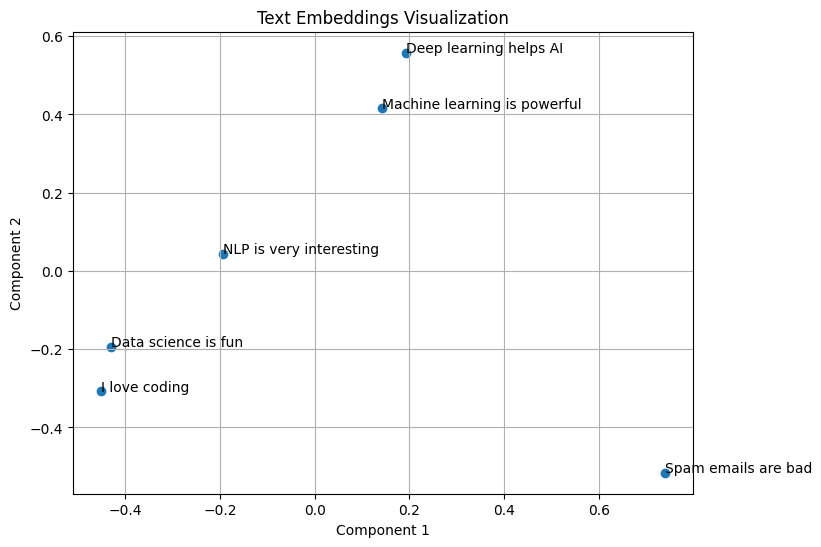

In [75]:

texts = [
    "NLP is very interesting",
    "Machine learning is powerful",
    "Deep learning helps AI",
    "I love coding",
    "Spam emails are bad",
    "Data science is fun"
]

embeddings = model.encode(texts)


pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:, 0], reduced[:, 1])

for i, t in enumerate(texts):
    plt.text(reduced[i, 0], reduced[i, 1], t)

plt.title("Text Embeddings Visualization")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True)
plt.show()

In [69]:
from collections import Counter
import re

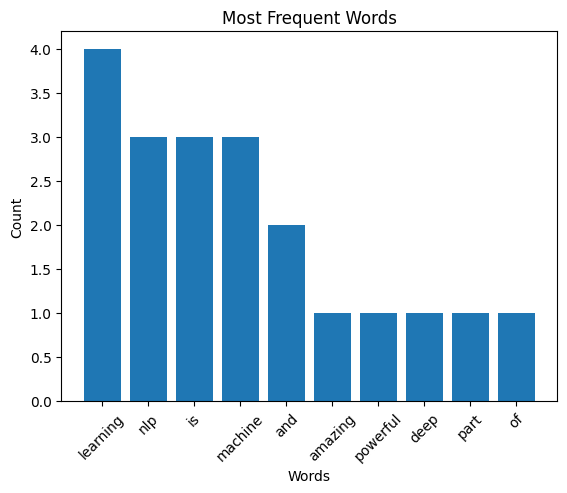

In [70]:
from collections import Counter
import re

texts = [
    "NLP is amazing and machine learning is powerful",
    "Deep learning is part of machine learning",
    "I love NLP and AI",
    "Machine learning makes NLP better"
]


all_text = " ".join(texts).lower()


words = re.findall(r'\w+', all_text)


freq = Counter(words)


most_common = freq.most_common(10)

words_list = [w[0] for w in most_common]
counts = [w[1] for w in most_common]


plt.figure()
plt.bar(words_list, counts)
plt.title("Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [72]:
ner = pipeline("ner", model="dslim/bert-base-NER", grouped_entities=True)

text = """
Apple is planning to open a new office in India.
Elon Musk founded SpaceX in California.
Microsoft is acquiring AI startups.
"""

result = ner(text)


data = []
for ent in result:
    data.append({
        "Entity": ent["word"],
        "Type": ent["entity_group"],
        "Score": round(ent["score"], 3)
    })

df = pd.DataFrame(data)
print(df)

Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:170: UserWarning: `grouped_entities` is deprecated and will be removed in version v5.0.0, defaulted to `aggregation_strategy="AggregationStrategy.SIMPLE"` instead.
  warnings.warn(


       Entity  Type  Score
0       Apple   ORG  0.999
1       India   LOC  1.000
2        Elon   ORG  0.914
3          Mu   PER  0.746
4        ##sk   ORG  0.776
5      SpaceX   ORG  0.999
6  California   LOC  1.000
7   Microsoft   ORG  0.999
8          AI  MISC  0.967


In [73]:
print(df)

       Entity  Type  Score
0       Apple   ORG  0.999
1       India   LOC  1.000
2        Elon   ORG  0.914
3          Mu   PER  0.746
4        ##sk   ORG  0.776
5      SpaceX   ORG  0.999
6  California   LOC  1.000
7   Microsoft   ORG  0.999
8          AI  MISC  0.967
